## **Capital Structure Lab — Optimal Leverage (Interactive)**
Apuntes de: Alejandro Vargas Sanchez, PhD, CFA

Use sliders to explore the optimum.

In [ ]:

import math, numpy as np, pandas as pd, matplotlib.pyplot as plt
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    WIDGETS_AVAILABLE = True
except Exception:
    from IPython.display import display, clear_output
    WIDGETS_AVAILABLE = False

def std_norm_cdf(x): return 0.5*(1+math.erf(x/math.sqrt(2)))
def merton_pd(A,D,sig,T=1.0):
    if D<=0 or A<=0 or sig<=0: return 0.0
    z=(math.log(A/D)-0.5*sig*sig*T)/(sig*math.sqrt(T))
    return max(0.0, min(1.0, 1.0-std_norm_cdf(z)))
def capital_structure_table(asset_value=40000.0, asset_turnover=0.40625, op_margin=0.40,
                            tax_rate=0.25, ro_unlevered=0.12, rd_base=0.06,
                            asset_vol=0.30, distress_severity=0.30, d_step_growth=0.25, n_steps=10):
    sales=asset_turnover*asset_value; ebit=op_margin*sales; cf=ebit*(1-tax_rate)
    Vu=cf/max(ro_unlevered,1e-9); D0=max(ebit,1e-9)
    import numpy as np, pandas as pd
    steps=np.arange(0,n_steps+1); D=D0*((1+d_step_growth)**steps)
    VL=Vu+tax_rate*D
    PD=np.array([merton_pd(asset_value,d,asset_vol,1.0) for d in D])
    DC=distress_severity*VL*PD; VL_adj=VL-DC
    E=VL-D; E2=np.maximum(E,1e-9)
    de=D/E2; Wd=np.clip(D/(D+E2),0,1); We=1-Wd
    WACC=np.full_like(D,np.nan,dtype=float); ok=VL_adj>1e-9; WACC[ok]=cf/VL_adj[ok]
    re=ro_unlevered+de*(ro_unlevered-rd_base)*(1-tax_rate)
    import pandas as pd
    df=pd.DataFrame({"step":steps,"Debt_D":D,"Equity_E":E,"Debt_to_Equity":de,"Weight_D":Wd,"Weight_E":We,
                     "Vu_unlevered":Vu,"VL_with_tax":VL,"PD_Merton":PD,"Distress_Cost":DC,
                     "VL_adjusted":VL_adj,"CF_unlevered":cf,"WACC_implied":WACC,"r_e_MM_tax":re})
    df["Feasible"]=(df["Equity_E"]>0)&(df["Weight_D"]<1.0)&(df["VL_adjusted"]>0)
    return df
def find_optimum(df, objective="min_wacc"):
    feas=df[df["Feasible"]].copy()
    if feas.empty: return int(df.index[0])
    return int((feas["VL_adjusted"].idxmax() if objective=="max_value" else feas["WACC_implied"].idxmin()))
def plot_wacc_feasible(df, idx):
    import numpy as np, matplotlib.pyplot as plt
    m=df["Feasible"]&np.isfinite(df["Debt_to_Equity"])&(df["Debt_to_Equity"]<10)
    x=df.loc[m,"Debt_to_Equity"].values; y=df.loc[m,"WACC_implied"].values
    plt.figure(figsize=(7,4.5)); plt.plot(x,y,marker="o",linestyle="-")
    if 0<=idx<len(df) and df.loc[idx,"Feasible"] and df.loc[idx,"Debt_to_Equity"]<10:
        plt.scatter([df.loc[idx,"Debt_to_Equity"]],[df.loc[idx,"WACC_implied"]],s=60)
        plt.title(f"WACC vs D/E (feasible) — Opt step {df.loc[idx,'step']}")
    else: plt.title("WACC vs D/E (feasible)")
    plt.xlabel("D/E ratio"); plt.ylabel("WACC (implied)"); plt.grid(True); plt.show()
def plot_value_feasible(df, idx):
    import numpy as np, matplotlib.pyplot as plt
    m=df["Feasible"]&np.isfinite(df["Debt_to_Equity"])&(df["Debt_to_Equity"]<10)
    x=df.loc[m,"Debt_to_Equity"].values; y=df.loc[m,"VL_adjusted"].values
    plt.figure(figsize=(7,4.5)); plt.plot(x,y,marker="o",linestyle="-")
    if 0<=idx<len(df) and df.loc[idx,"Feasible"] and df.loc[idx,"Debt_to_Equity"]<10:
        plt.scatter([df.loc[idx,"Debt_to_Equity"]],[df.loc[idx,"VL_adjusted"]],s=60)
        plt.title(f"Adjusted Firm Value vs D/E (feasible) — Opt step {df.loc[idx,'step']}")
    else: plt.title("Adjusted Firm Value vs D/E (feasible)")
    plt.xlabel("D/E ratio"); plt.ylabel("VL (adjusted)"); plt.grid(True); plt.show()


,step,Debt_D,Equity_E,Debt_to_Equity,Weight_D,Weight_E,Vu_unlevered,VL_with_tax,PD_Merton,Distress_Cost,VL_adjusted,CF_unlevered,WACC_implied,r_e_MM_tax,Feasible
0,0,6500.000000,35750.000000,0.181818,0.153846,0.846154,40625.0,42250.000000,1.742769e-09,0.000022,42249.999978,4875.0,0.115385,0.128182,True
1,1,8125.000000,34531.250000,0.235294,0.190476,0.809524,40625.0,42656.250000,1.214386e-07,0.001554,42656.248446,4875.0,0.114286,0.130588,True
2,2,10156.250000,33007.812500,0.307692,0.235294,0.764706,40625.0,43164.062500,4.951042e-06,0.064112,43163.998388,4875.0,0.112941,0.133846,True
3,3,12695.312500,31103.515625,0.408163,0.289855,0.710145,40625.0,43798.828125,1.186973e-04,1.559640,43797.268485,4875.0,0.111308,0.138367,True
4,4,15869.140625,28723.144531,0.552486,0.355872,0.644128,40625.0,44592.285156,1.685686e-03,22.550583,44569.734573,4875.0,0.109379,0.144862,True


,6
step,6
Debt_D,24795.532227
Equity_E,22028.35083
Debt_to_Equity,1.125619
Weight_D,0.529549
WACC_implied,0.106489
VL_adjusted,45779.307762
PD_Merton,0.074362
r_e_MM_tax,0.170653


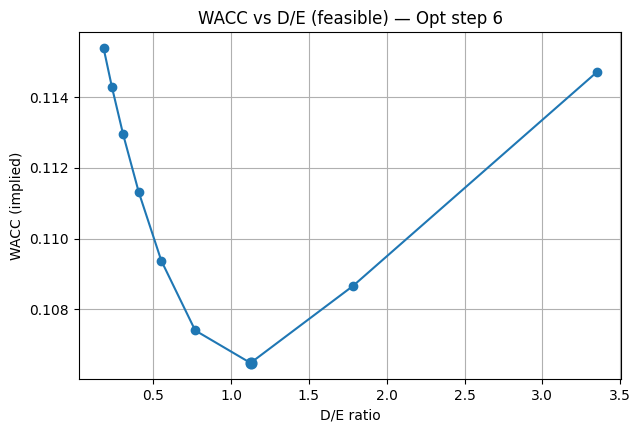

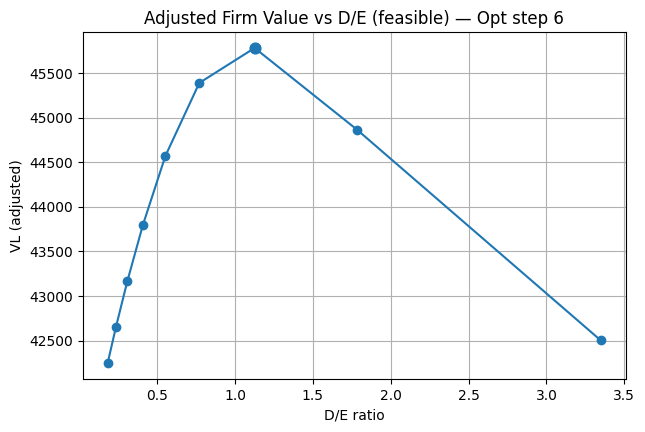

In [ ]:

# Baseline run
df = capital_structure_table()
idx = find_optimum(df, "min_wacc")
display(df.head())
display(df.loc[idx, ["step","Debt_D","Equity_E","Debt_to_Equity","Weight_D","WACC_implied","VL_adjusted","PD_Merton","r_e_MM_tax"]])
plot_wacc_feasible(df, idx); plot_value_feasible(df, idx)


In [ ]:

# Interactive (requires ipywidgets)
if WIDGETS_AVAILABLE:
    s_asset_value = widgets.FloatSlider(description="Assets (A)", value=40000.0, min=5000, max=200000, step=1000, continuous_update=False)
    s_turnover    = widgets.FloatSlider(description="Asset Turnover", value=0.40625, min=0.05, max=2.0, step=0.01, continuous_update=False)
    s_margin      = widgets.FloatSlider(description="Op Margin", value=0.40, min=0.05, max=0.70, step=0.01, continuous_update=False)
    s_tax         = widgets.FloatSlider(description="Tax Rate T", value=0.25, min=0.0, max=0.45, step=0.01, continuous_update=False)
    s_ro          = widgets.FloatSlider(description="r_o (unlev.)", value=0.12, min=0.06, max=0.25, step=0.005, continuous_update=False)
    s_rd0         = widgets.FloatSlider(description="r_d base", value=0.06, min=0.02, max=0.20, step=0.005, continuous_update=False)
    s_vol         = widgets.FloatSlider(description="σ_A", value=0.30, min=0.05, max=0.80, step=0.01, continuous_update=False)
    s_sev         = widgets.FloatSlider(description="Distress Sev", value=0.30, min=0.0, max=0.70, step=0.01, continuous_update=False)
    s_step        = widgets.FloatSlider(description="D step", value=0.25, min=0.05, max=0.60, step=0.01, continuous_update=False)
    s_n           = widgets.IntSlider(description="# steps", value=10, min=4, max=20, step=1, continuous_update=False)
    s_obj         = widgets.Dropdown(description="Objective", options=[("Min WACC","min_wacc"),("Max VL_adj","max_value")], value="min_wacc")
    out = widgets.Output()
    def update(*_):
        with out:
            clear_output(wait=True)
            df_ = capital_structure_table(asset_value=s_asset_value.value, asset_turnover=s_turnover.value, op_margin=s_margin.value,
                                          tax_rate=s_tax.value, ro_unlevered=s_ro.value, rd_base=s_rd0.value, asset_vol=s_vol.value,
                                          distress_severity=s_sev.value, d_step_growth=s_step.value, n_steps=s_n.value)
            idx_ = find_optimum(df_, s_obj.value)
            display(df_.loc[idx_, ["step","Debt_D","Equity_E","Debt_to_Equity","Weight_D","WACC_implied","VL_adjusted","PD_Merton","r_e_MM_tax"]])
            plot_wacc_feasible(df_, idx_); plot_value_feasible(df_, idx_)
    for w in [s_asset_value, s_turnover, s_margin, s_tax, s_ro, s_rd0, s_vol, s_sev, s_step, s_n, s_obj]:
        w.observe(update, names="value")
    display(widgets.VBox([widgets.HBox([s_asset_value, s_turnover, s_margin]),
                          widgets.HBox([s_tax, s_ro, s_rd0]),
                          widgets.HBox([s_vol, s_sev]),
                          widgets.HBox([s_step, s_n, s_obj]), out]))
    update()
else:
    print("ipywidgets not available. Install with: pip install ipywidgets")
